# Exploration: a machine learning way to infer ODE directly from the data (full trajectory)

Constrained ODE: dT/dt = 0.00501893723929178*E**3 - 0.00182524395779452*E**2*T + 0.0179158254729358*E**2 + 0.00205152190122369*E*T**2 - 0.00118900591712949*E*T - 0.0578182623198872*E - 0.00431318594941269*T**3


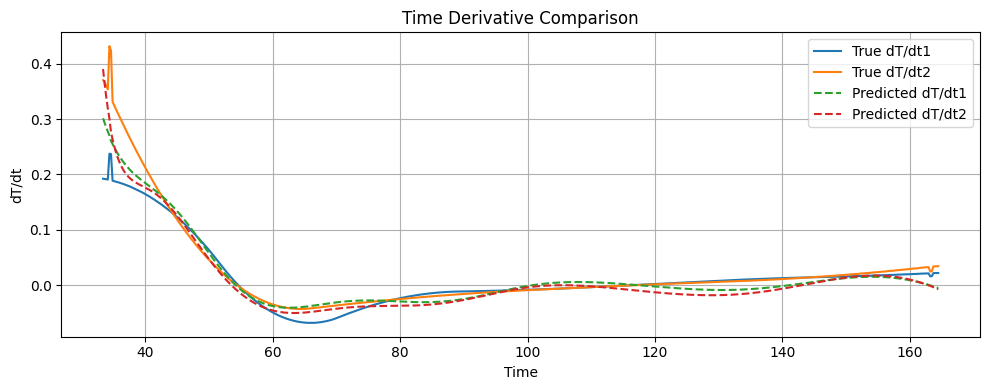

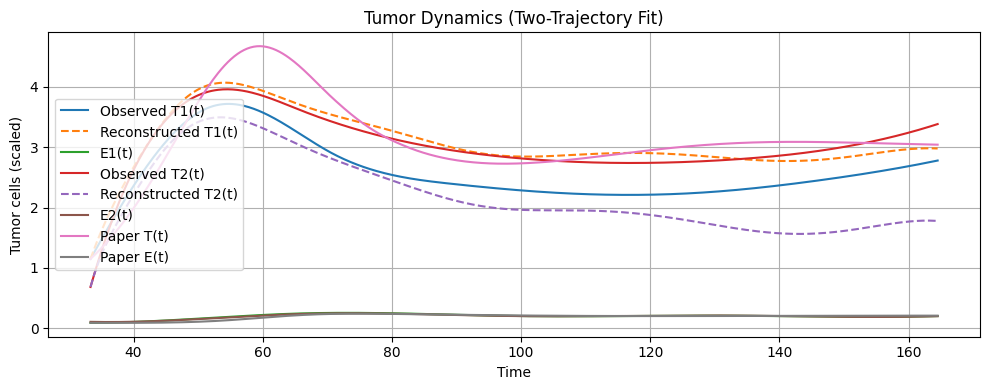

No Treatment ODE: dT/dt = -0.00431318594941269*T**3


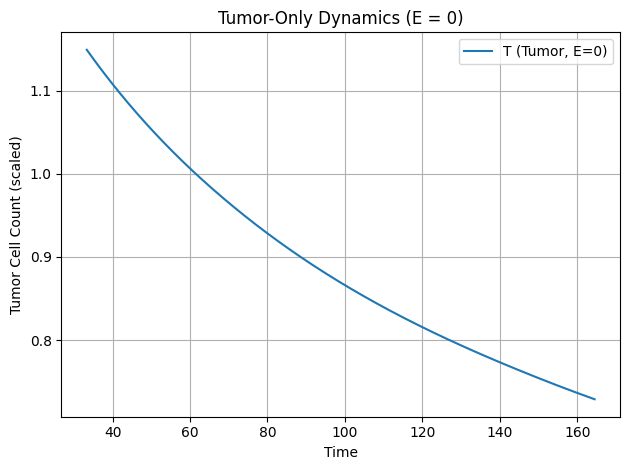

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sympy.parsing.sympy_parser import parse_expr, standard_transformations, convert_xor
from scipy.signal import savgol_filter
from scipy.integrate import solve_ivp, cumulative_trapezoid
import cvxpy as cp
import warnings

warnings.filterwarnings("ignore")

# === Load Data ===
df: pd.DataFrame = pd.read_csv("data/splined_trajectories_ETratio_low.csv")
obs_T1: np.ndarray = np.array(df["tumor_cells_trial1_(ci)"])
obs_T2: np.ndarray = np.array(df["tumor_cells_trial2_(ci)"])
obs_E1: np.ndarray = np.array(df["cart_cells_trial1_(ci)"])
obs_E2: np.ndarray = np.array(df["cart_cells_trial2_(ci)"])
t_eval: np.ndarray = np.array(df["time_trial_(hrs)"])
t_span: tuple = (t_eval[0], t_eval[-1])
n: int = len(obs_T1)


# === Paper ODE Simulation ===
def ode_system(t, z) -> list:
    x, y = z
    dxdt = 0.15 * x - 0.012 * x**2 - 0.545 * x * y
    dydt = -0.002 * x * y + 0.005 * x**2 * y - 0.063 * x * y**2
    return [dxdt, dydt]


initial_condition: list = [obs_T1[0], obs_E1[0]]
sol = solve_ivp(ode_system, t_span, initial_condition, t_eval=t_eval)
paper_tumor: np.ndarray = sol.y[0]
paper_treatment: np.ndarray = sol.y[1]

# === Smooth and Derivative ===
T1_smooth: np.ndarray = savgol_filter(obs_T1, window_length=10, polyorder=3)
T2_smooth: np.ndarray = savgol_filter(obs_T2, window_length=10, polyorder=3)
dTdt1: np.ndarray = np.gradient(T1_smooth, t_eval)
dTdt2: np.ndarray = np.gradient(T2_smooth, t_eval)

# === Combine Trials ===
T_combined: np.ndarray = np.concatenate([T1_smooth, T2_smooth])
E_combined: np.ndarray = np.concatenate([obs_E1, obs_E2])
dTdt_combined: np.ndarray = np.concatenate([dTdt1, dTdt2])

# === Design Matrix ===
X_raw = np.vstack([T_combined, E_combined]).T
scaler = StandardScaler()
X_scaled: np.ndarray = scaler.fit_transform(X_raw)
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly: np.ndarray = poly.fit_transform(X_scaled)
terms: np.ndarray = poly.get_feature_names_out(["T", "E"])

# === Constrained Regression ===
w = cp.Variable(X_poly.shape[1])
objective = cp.Minimize(cp.sum_squares(X_poly @ w - dTdt_combined))

constraints: list = []
for i, term in enumerate(terms):
    if term == "T":
        constraints.append(w[i] >= 0)
    elif term in {"T^2", "T E"}:
        constraints.append(w[i] <= 0)

problem = cp.Problem(objective, constraints)
problem.solve()
constrained_coef: np.ndarray | None = w.value

# === Build Symbolic Expression ===
T, E = sp.symbols("T E")
transformations: tuple = standard_transformations + (convert_xor,)
symbol_map: dict = {"T": T, "E": E}
expr = 0
for c, term in zip(constrained_coef, terms):  # pyright: ignore[reportArgumentType]
    if abs(c) > 1e-6:
        parsed = parse_expr(term.replace(" ", "*"), local_dict=symbol_map, transformations=transformations)
        expr += c * parsed
expr = sp.simplify(expr)
expr_expanded = sp.expand(expr)
print("Constrained ODE: dT/dt =", expr_expanded)

# === Predict and Reconstruct T1, T2 ===
pred_dTdt: np.ndarray = X_poly @ constrained_coef
pred_dTdt1: np.ndarray = pred_dTdt[:n]
pred_dTdt2: np.ndarray = pred_dTdt[n:]
reconstructed_T1: np.ndarray = obs_T1[0] + cumulative_trapezoid(pred_dTdt1, t_eval, initial=0)
reconstructed_T2: np.ndarray = obs_T2[0] + cumulative_trapezoid(pred_dTdt2, t_eval, initial=0)

# === Plot Derivative Comparison ===
plt.figure(figsize=(10, 4))
plt.plot(t_eval, dTdt1, label="True dT/dt1")
plt.plot(t_eval, dTdt2, label="True dT/dt2")
plt.plot(t_eval, pred_dTdt1, "--", label="Predicted dT/dt1")
plt.plot(t_eval, pred_dTdt2, "--", label="Predicted dT/dt2")
plt.xlabel("Time")
plt.ylabel("dT/dt")
plt.title("Time Derivative Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Plot T Reconstruction ===
plt.figure(figsize=(10, 4))
plt.plot(t_eval, obs_T1, label="Observed T1(t)")
plt.plot(t_eval, reconstructed_T1, "--", label="Reconstructed T1(t)")
plt.plot(t_eval, obs_E1, label="E1(t)")
plt.plot(t_eval, obs_T2, label="Observed T2(t)")
plt.plot(t_eval, reconstructed_T2, "--", label="Reconstructed T2(t)")
plt.plot(t_eval, obs_E2, label="E2(t)")
plt.plot(t_eval, paper_tumor, label="Paper T(t)")
plt.plot(t_eval, paper_treatment, label="Paper E(t)")
plt.xlabel("Time")
plt.ylabel("Tumor cells (scaled)")
plt.title("Tumor Dynamics (Two-Trajectory Fit)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Simulate T dynamics with E = 0 ===
expr_no_E = sp.Add(*[term for term in expr_expanded.as_ordered_terms() if not term.has(E)])
expr_no_E_func = sp.lambdify(T, expr_no_E, modules="numpy")
print("No Treatment ODE: dT/dt =", expr_no_E)


def ode_system_T_only(t, y) -> list:
    return [expr_no_E_func(y[0])]


initial_condition = [obs_T1[0]]
sol = solve_ivp(ode_system_T_only, t_span, initial_condition, t_eval=t_eval)

# === Plot Tumor-Only Dynamics ===
plt.plot(sol.t, sol.y[0], label="T (Tumor, E=0)")
plt.xlabel("Time")
plt.ylabel("Tumor Cell Count (scaled)")
plt.title("Tumor-Only Dynamics (E = 0)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()